# Parking Lot Entry Booth: Discrete-Event Simulation Study
**CSS142P Modelling and Simulation · Group 8** (Ariola, Bauza, Caliliw, Jimenez)
School of Information Technology, Mapúa University

**Decision question.** On high-traffic days, should the Makati campus parking lot staff a second entry booth from 07:00 to 09:00, or keep one booth all day?

**Measures (proposal Part 4).** Average waiting time (min), maximum queue length (vehicles), booth utilization over staffed booth-time, and spillover duration (minutes the queue holds at least *K* vehicles).

This notebook follows the 10-step study process: input modelling → conceptual model → verification → experiment → output analysis → validation → sensitivity → report. All model logic lives in `parking_sim.py`; this notebook only calls it, so every number below can be regenerated from the files in `data/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import parking_sim as ps

DATA, RESULTS, FIGS = Path("data"), Path("results"), Path("figures")
RESULTS.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

N_REPS = 30                         # proposal Part 6
SEEDS = list(range(1, N_REPS + 1))  # one seed per replication, shared by both configurations (CRN)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

site = pd.read_csv(DATA / "site_measurements.csv").iloc[0]
PLACEHOLDER = str(site["measured_on"]).strip().upper() == "PLACEHOLDER"
if PLACEHOLDER:
    print("WARNING: data/ still contains PLACEHOLDER inputs. The pipeline runs, but results are\n"
          "illustrative only until the gate log, stopwatch timings, and site measurement are replaced.")

illustrative only until the gate log, stopwatch timings, and site measurement are replaced.


## 1. Input modelling
### 1.1 Arrivals: piecewise-constant Poisson rates
Arrivals per 15-minute interval come from the gate entry log. If `data/peak_arrival_tally.csv` contains counts, they replace the log for those intervals. This matters because the gate log timestamps the moment a vehicle **passes the booth**, not when it joins the queue. While a queue exists, passages per interval are capped by booth capacity, so the log under-counts true peak demand. A tally taken at the tail of the queue records real arrivals.

Each interval's rate is λ = count / 15 vehicles per minute.

In [2]:
arr = ps.load_arrival_counts(DATA / "gate_entry_log.csv", DATA / "peak_arrival_tally.csv")
rates = arr["rate_per_min"].to_numpy()
print(f"Vehicles in log: {arr['count'].sum()}   |   07:00-09:00: {arr['count'][:8].sum()}   |   "
      f"sources used: {', '.join(arr['source'].unique())}")
arr.head(10)

Vehicles in log: 453   |   07:00-09:00: 220   |   sources used: gate log


,interval_start,t_start_min,count,source,rate_per_min
0,07:00,0.0,17,gate log,1.133
1,07:15,15.0,31,gate log,2.067
2,07:30,30.0,42,gate log,2.800
3,07:45,45.0,38,gate log,2.533
4,08:00,60.0,29,gate log,1.933
5,08:15,75.0,19,gate log,1.267
6,08:30,90.0,25,gate log,1.667
7,08:45,105.0,19,gate log,1.267
8,09:00,120.0,14,gate log,0.933
9,09:15,135.0,10,gate log,0.667


### 1.2 Processing (service) times
Sixty stopwatch timings: 30 in the peak window and 30 off-peak. Following the input-modelling steps (inspect → choose candidates → estimate → assess), the three candidate families named in the proposal are fitted to each window. If the windows do not differ, they are fitted to the pooled 60 timings instead. A family is chosen by this rule: among fits **not rejected** by the chi-square test at 5%, take the lowest AIC.

First, check whether peak and off-peak times differ enough to need separate distributions (Mann–Whitney U test).

In [3]:
svc = pd.read_csv(DATA / "service_times.csv")
svc["service_min"] = svc["service_sec"] / 60
peak_x = svc.loc[svc.window == "peak", "service_min"].to_numpy()
off_x  = svc.loc[svc.window == "offpeak", "service_min"].to_numpy()

display(svc.groupby("window")["service_sec"].describe().round(1))
mw = stats.mannwhitneyu(peak_x, off_x, alternative="two-sided")
SEPARATE = mw.pvalue < 0.05
print(f"Mann-Whitney U = {mw.statistic:.0f}, p = {mw.pvalue:.4f} -> "
      + ("peak and off-peak times differ: fit each window separately."
         if SEPARATE else "no evidence of a difference: pool all 60 timings into one distribution."))

,count,mean,std,min,25%,50%,75%,max
window,,,,,,,,
offpeak,30.0,31.4,12.4,11.9,24.5,28.8,36.9,69.5
peak,30.0,27.4,9.2,9.1,22.0,25.8,35.0,48.9


Mann-Whitney U = 368, p = 0.2282 -> no evidence of a difference: pool all 60 timings into one distribution.


In [4]:
samples = {"peak": peak_x, "offpeak": off_x} if SEPARATE else {"pooled": np.r_[peak_x, off_x]}

def service_model(family):
    # family: one name for all windows, or a dict {window: name}
    d = {w: ps.fit_distribution(x, family[w] if isinstance(family, dict) else family) for w, x in samples.items()}
    return ps.ServiceModel(d if SEPARATE else {"peak": d["pooled"], "offpeak": d["pooled"]})

fit_tables, chosen = [], {}
for w, x in samples.items():
    best, tab = ps.select_distribution(x)
    tab.insert(0, "window", w)
    fit_tables.append(tab); chosen[w] = best
fit_summary = pd.concat(fit_tables, ignore_index=True)
fit_summary.to_csv(RESULTS / "input_fit_summary.csv", index=False)

SERVICE = service_model(chosen)
print("Selected:", chosen)
fit_summary[["window","family","chi2","dof","chi2_crit_5pct","chi2_p","ks_p","aic","fit_mean","sample_mean","selected"]]

Selected: {'pooled': 'lognormal'}


,window,family,chi2,dof,chi2_crit_5pct,chi2_p,ks_p,aic,fit_mean,sample_mean,selected
0,pooled,exponential,68.333,8,15.507,1.054e-11,4.355e-07,36.446,0.490,0.49,False
1,pooled,lognormal,14.000,7,14.067,5.118e-02,6.994e-01,-35.189,0.492,0.49,True
2,pooled,triangular,15.667,6,12.592,1.566e-02,1.820e-03,-23.483,0.560,0.49,False


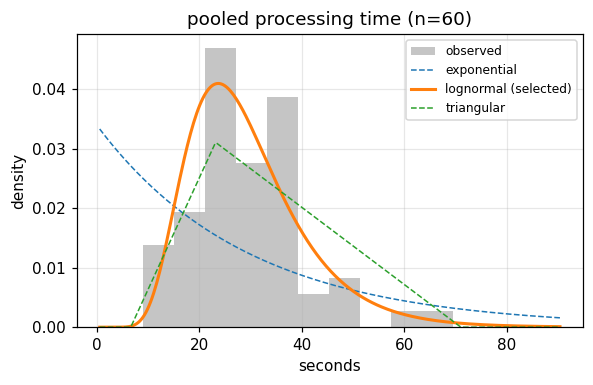

In [5]:
fig, axes = plt.subplots(1, len(samples), figsize=(5.5 * len(samples), 3.6), sharey=True)
for ax, (w, x) in zip(np.atleast_1d(axes), samples.items()):
    ax.hist(x * 60, bins=10, density=True, alpha=0.45, color="grey", label="observed")
    grid = np.linspace(0.01, x.max() * 1.3, 300)
    for fam in ps.CANDIDATES:
        d = ps.fit_distribution(x, fam)
        ax.plot(grid * 60, d.pdf(grid) / 60, lw=2 if fam == chosen[w] else 1,
                ls="-" if fam == chosen[w] else "--", label=fam + (" (selected)" if fam == chosen[w] else ""))
    ax.set_title(f"{w} processing time (n={len(x)})"); ax.set_xlabel("seconds")
np.atleast_1d(axes)[0].set_ylabel("density"); np.atleast_1d(axes)[-1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "service_time_fits.png"); plt.show()

With only 30 to 60 observations, goodness-of-fit tests have low power: "not rejected" does not mean "proven correct". Section 8.2 therefore reruns the study under every candidate family to check whether the choice changes the recommendation.

### 1.3 Approach capacity *K*
*K* = usable approach length ÷ (average vehicle length + gap), rounded down: the number of vehicles that fit before the tail reaches Pablo Ocampo Sr. Extension.

In [6]:
K = int(site["approach_length_m"] // (site["avg_vehicle_length_m"] + site["avg_gap_m"]))
print(f"{site['approach_length_m']} m / ({site['avg_vehicle_length_m']} + {site['avg_gap_m']}) m  ->  K = {K} vehicles")

30.0 m / (4.6 + 1.4) m  ->  K = 5 vehicles


### 1.4 Load check before simulating: utilization by interval
For each interval, offered load is ρ = λ · E[S] / c. The Week 2 lesson applies: as ρ approaches 1, delay grows sharply, and when ρ > 1 the queue must grow for that whole interval. This analytic screen shows *where* trouble should appear. The simulation then measures *how much*.

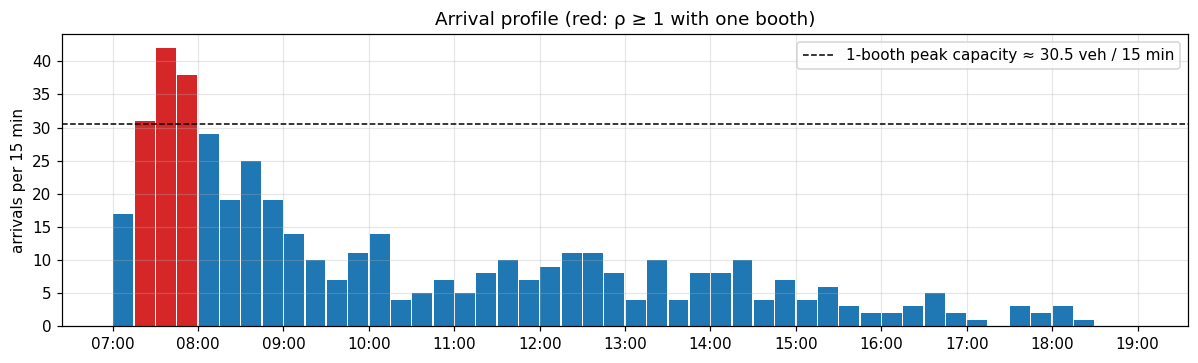

,interval_start,count,rate_per_min,rho_1_booth,rho_2_booths
0,07:00,17,1.133,0.557,0.279
1,07:15,31,2.067,1.016,0.508
2,07:30,42,2.800,1.377,0.689
3,07:45,38,2.533,1.246,0.623
4,08:00,29,1.933,0.951,0.475
5,08:15,19,1.267,0.623,0.311
6,08:30,25,1.667,0.820,0.410
7,08:45,19,1.267,0.623,0.311
8,09:00,14,0.933,0.459,0.459
9,09:15,10,0.667,0.328,0.328


In [7]:
arr["mean_service_min"] = np.where(arr["t_start_min"] < ps.PEAK_END, SERVICE.dists["peak"].mean(), SERVICE.dists["offpeak"].mean())
arr["rho_1_booth"] = arr["rate_per_min"] * arr["mean_service_min"]
arr["rho_2_booths"] = np.where(arr["t_start_min"] < ps.PEAK_END, arr["rho_1_booth"] / 2, arr["rho_1_booth"])
arr.to_csv(RESULTS / "arrival_rates_and_load.csv", index=False)

cap1 = 1 / SERVICE.dists["peak"].mean() * 15
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(arr["t_start_min"] + 7.5, arr["count"], width=14, color=["tab:red" if r >= 1 else "tab:blue" for r in arr["rho_1_booth"]])
ax.axhline(cap1, color="k", ls="--", lw=1, label=f"1-booth peak capacity ≈ {cap1:.1f} veh / 15 min")
ax.set_xticks(np.arange(0, 721, 60)); ax.set_xticklabels([ps.min_to_clock(t) for t in range(0, 721, 60)])
ax.set_ylabel("arrivals per 15 min"); ax.set_title("Arrival profile (red: ρ ≥ 1 with one booth)"); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "arrival_profile.png"); plt.show()
arr.loc[:9, ["interval_start","count","rate_per_min","rho_1_booth","rho_2_booths"]]

## 2. Conceptual model
**Classification.** The model is **dynamic** because the order and timing of arrivals determine waiting. It is **stochastic** because interarrival and processing times vary. It is **discrete** because queue length and booth status change only at events.

| Element | In this model |
|---|---|
| Entity | vehicle (attributes: arrival time, processing time) |
| Resource | entry booth(s); one vehicle at a time each |
| State | vehicles waiting; each booth busy/idle and open/closed |
| Events | arrival · processing start · processing completion · second-booth closing (09:00) |
| Activity (sampled) | processing time |
| Delay (output) | time in queue |
| Study type | **terminating**: 07:00 start empty, arrivals stop 19:00, queue cleared. No warm-up is discarded because the empty start is the real condition being studied. |

**Assumptions** (C = confirmed fact, P = provisional modelling choice):

| # | Assumption | Status | Reason / effect |
|---|---|---|---|
| A1 | Arrivals are Poisson with a rate that is constant within each 15-min interval | P | Standard for independent arrivals; rate changes capture the peak. Tested by sensitivity on arrival scale. |
| A2 | Processing time depends on arrival window (peak/off-peak), fitted from stopwatch data | P | Section 1.2. Tested by distribution-family sensitivity. |
| A3 | Two-booth configuration uses **one shared queue** that feeds whichever booth frees first | P | Proposal does not specify the lane layout. A shared queue is the best case; two separate lanes where drivers choose would do somewhat worse. |
| A4 | At 09:00 the second booth finishes its current vehicle, then accepts no more | P | Non-preemptive close; staffed time extends to that finish. |
| A5 | Second booth draws processing times from the same distribution as the first | P | Stated in proposal Part 5. |
| A6 | No balking, reneging, parking-space limit, or exit interaction | C (scope) | Proposal Part 2, out of scope. |
| A7 | Queue is empty and booth idle at 07:00 | P | Proposal Part 2. If cars wait before opening, the real start is not empty (see limitations). |
| A8 | Spillover when the **waiting** queue (excluding the vehicle at the booth) holds ≥ *K* | P | Direct reading of the proposal's definition. |

## 3. Verification: did we build the model right?
Each check below compares the code with the design, not with the real system. All results are written to `results/verification_checks.csv`, and the checks should be rerun after every model change.

In [8]:
checks = []
def check(name, expected, observed, passed):
    checks.append({"check": name, "expected": str(expected), "observed": str(observed), "pass": bool(passed)})

# V1 - Hand trace from the DES lecture (interarrivals 2,4,1,3; services 3,2,4,1)
r = ps.simulate_day(np.array([2., 6, 7, 10]), np.array([3., 2, 4, 1]), ps.ONE_BOOTH)
w = r.start - r.arrival
check("V1 hand trace: delays", "[0, 0, 1, 2]", [float(v) for v in w], np.allclose(w, [0, 0, 1, 2]))
check("V1 hand trace: Wq and utilization", "Wq=0.75, util=10/13=0.769",
      f"Wq={w.mean():.2f}, util={r.booths[0].busy_time / r.finish.max():.3f}",
      np.isclose(w.mean(), 0.75) and np.isclose(r.booths[0].busy_time / r.finish.max(), 10 / 13))

# V2 - Deterministic queue from Week 2: arrival every 1.00 min, service 0.99 min -> no waiting
r = ps.simulate_day(np.arange(0, 100, 1.0), np.full(100, 0.99), ps.ONE_BOOTH)
check("V2 deterministic D/D/1 (Week 2): no wait", 0.0, float((r.start - r.arrival).max()), (r.start - r.arrival).max() == 0)

# V3-V6 on the real experiment inputs, every replication, both configurations
exp_df, days = ps.run_experiment(SEEDS, rates, SERVICE, K, keep_days=True, extra_K=(max(K - 1, 1), K + 1))
cons_ok = little_ok = sane_ok = close_ok = fifo_ok = crn_ok = True
for (seed, cfg), d in days.items():
    s = d.snapshot_close
    cons_ok &= s["arrived"] == s["finished"] + s["waiting"] + s["in_service"]
    cons_ok &= np.all(np.isfinite(d.finish))                           # everyone eventually served
    wait = d.start - d.arrival
    sane_ok &= wait.min() >= -1e-9 and d.trace_q.min() >= 0
    fifo_ok &= np.all(np.diff(d.start) >= -1e-9)                       # single queue, first come first served
    area = np.sum((np.append(d.trace_t[1:], d.trace_t[-1]) - d.trace_t) * d.trace_q)
    little_ok &= np.isclose(area, wait.sum(), rtol=1e-9)               # Lq*T = sum of delays (Little)
    if d.config.extra_booths:
        close_ok &= not np.any((d.booth == 2) & (d.start > ps.PEAK_END + 1e-9))
for seed in SEEDS:
    a, b = days[(seed, ps.CONFIGS[0].name)], days[(seed, ps.CONFIGS[1].name)]
    crn_ok &= np.array_equal(a.arrival, b.arrival) and np.allclose(a.finish - a.start, b.finish - b.start)
util_ok = exp_df["utilization"].between(0, 1).all() and exp_df["peak_utilization"].between(0, 1).all()

check("V3 conservation at 19:00: arrived = finished + waiting + in service (all 60 runs)", "equal", "equal" if cons_ok else "MISMATCH", cons_ok)
check("V4 sanity: waits >= 0, queue >= 0, utilization in [0,1]", "true", sane_ok and util_ok, sane_ok and util_ok)
check("V5 FIFO: service starts in arrival order", "true", fifo_ok, fifo_ok)
check("V6 Little's law identity: queue-length area = sum of delays", "equal", little_ok, little_ok)
check("V7 second booth starts no vehicle after 09:00", "0 starts", "0 starts" if close_ok else "violations", close_ok)
check("V8 common random numbers: both configs see identical arrivals and processing times", "identical", crn_ok, crn_ok)

**Known-answer tests (steady-state, separate from the main study).** With constant-rate Poisson arrivals and exponential service, queueing theory gives the exact long-run delay: M/M/1 (Week 2) and M/M/2 via Erlang C. These runs are steady-state studies, so a 1,000-minute warm-up is discarded. They exercise the same `simulate_day` code, including the two-booth path.

In [9]:
def known_answer(lam, mean_s, booths, reps=20, horizon=20000, warm=1000):
    cfg = ps.Config("test", base_booths=booths, extra_booths=0)
    est = []
    for seed in range(1000, 1000 + reps):
        rng = np.random.default_rng(seed)
        a = np.cumsum(rng.exponential(1 / lam, int(lam * horizon * 1.1)))
        a = a[a < horizon]
        d = ps.simulate_day(a, rng.exponential(mean_s, len(a)), cfg, day_length=horizon)
        keep = d.arrival >= warm
        est.append((d.start - d.arrival)[keep].mean())
    return ps.ci_mean(est)

for lam, mean_s, c in [(0.8, 1.0, 1), (1.6, 1.0, 2)]:
    theory = ps.mm1_wq(lam, 1 / mean_s) if c == 1 else ps.mmc_wq(lam, 1 / mean_s, c)
    ci = known_answer(lam, mean_s, c)
    check(f"V9 known answer M/M/{c} (lambda={lam}, E[S]={mean_s}): Wq",
          f"{theory:.3f} (theory)", f"{ci['mean']:.3f} [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]",
          ci["ci_low"] <= theory <= ci["ci_high"])

ver = pd.DataFrame(checks); ver.to_csv(RESULTS / "verification_checks.csv", index=False)
print(f"{ver['pass'].sum()} / {len(ver)} checks passed")
ver

11 / 11 checks passed


,check,expected,observed,pass
0,V1 hand trace: delays,"[0, 0, 1, 2]","[0.0, 0.0, 1.0, 2.0]",True
1,V1 hand trace: Wq and utilization,"Wq=0.75, util=10/13=0.769","Wq=0.75, util=0.769",True
2,V2 deterministic D/D/1 (Week 2): no wait,0.0,0.0,True
3,V3 conservation at 19:00: arrived = finished +...,equal,equal,True
4,"V4 sanity: waits >= 0, queue >= 0, utilization...",true,True,True
5,V5 FIFO: service starts in arrival order,true,True,True
6,V6 Little's law identity: queue-length area = ...,equal,True,True
7,V7 second booth starts no vehicle after 09:00,0 starts,0 starts,True
8,V8 common random numbers: both configs see ide...,identical,True,True
9,"V9 known answer M/M/1 (lambda=0.8, E[S]=1.0): Wq",4.000 (theory),"3.981 [3.838, 4.124]",True


## 4. Experiment design
| Item | Setting |
|---|---|
| Study type | Terminating, one operating day (07:00 to queue cleared after 19:00) |
| Warm-up | None (the empty 07:00 start is part of the question) |
| Configurations | 1 booth all day · 2 booths 07:00–09:00 |
| Replications | 30 per configuration, seeds 1–30 |
| Variance reduction | Common random numbers: each seed produces one arrival stream and one processing-time stream, and both configurations see exactly the same vehicles (verified in V8) |
| Analysis | 95% t-intervals per configuration, plus a **paired**-t interval on the per-seed difference |

The experiment was already run inside the verification cell (`exp_df`); raw replication output is saved next.

In [10]:
exp_df.drop(columns=[c for c in exp_df.columns if c.startswith("_")]).to_csv(RESULTS / "replications_raw.csv", index=False)
exp_df[["seed","config","avg_wait_min","max_queue_veh","utilization","spillover_min","n_vehicles"]].head(6)

,seed,config,avg_wait_min,max_queue_veh,utilization,spillover_min,n_vehicles
0,1,1 booth all day,2.194,20,0.320,73.492,457
1,1,2 booths 07:00-09:00,0.151,5,0.274,0.768,457
2,2,1 booth all day,3.228,29,0.311,81.770,450
3,2,2 booths 07:00-09:00,0.085,5,0.266,0.009,450
4,3,1 booth all day,3.674,32,0.316,82.378,460
5,3,2 booths 07:00-09:00,0.093,4,0.271,0.000,460


## 5. Results
### 5.1 Each configuration: mean with 95% confidence interval (n = 30)

In [11]:
MEASURES = {  # column: (label, is proposal measure)
    "avg_wait_min": ("Average waiting time (min)", True),
    "max_queue_veh": ("Maximum queue length (vehicles)", True),
    "utilization": ("Booth utilization, staffed time (fraction)", True),
    "spillover_min": (f"Spillover duration, queue >= K={K} (min)", True),
    "avg_wait_peak_arrivals_min": ("Avg wait, vehicles arriving 07:00-09:00 (min)", False),
    "p90_wait_min": ("90th-percentile wait (min)", False),
    "peak_utilization": ("Utilization inside 07:00-09:00 (fraction)", False),
    "spillover_peak_min": ("Spillover inside 07:00-09:00 (min)", False),
    "vehicles_queued_on_road": ("Vehicles that joined the queue on the road", False),
}
rows = []
for cfg in [c.name for c in ps.CONFIGS]:
    sub = exp_df[exp_df.config == cfg]
    for col, (label, core) in MEASURES.items():
        rows.append({"configuration": cfg, "measure": label, "proposal_measure": core, **ps.ci_mean(sub[col])})
summary = pd.DataFrame(rows); summary.to_csv(RESULTS / "summary_by_config.csv", index=False)
summary.pivot(index="measure", columns="configuration", values="mean").join(
    summary.pivot(index="measure", columns="configuration", values="half_width").add_suffix(" ±hw")).round(3)

configuration,1 booth all day,2 booths 07:00-09:00,1 booth all day ±hw,2 booths 07:00-09:00 ±hw
measure,,,,
90th-percentile wait (min),9.542,0.438,1.118,0.041
Average waiting time (min),2.720,0.113,0.400,0.011
"Avg wait, vehicles arriving 07:00-09:00 (min)",5.459,0.115,0.764,0.015
"Booth utilization, staffed time (fraction)",0.308,0.264,0.007,0.006
Maximum queue length (vehicles),26.800,4.633,2.603,0.410
"Spillover duration, queue >= K=5 (min)",71.189,0.334,6.353,0.303
Spillover inside 07:00-09:00 (min),70.575,0.331,6.040,0.303
Utilization inside 07:00-09:00 (fraction),0.879,0.443,0.021,0.012
Vehicles that joined the queue on the road,140.067,0.567,12.606,0.725


### 5.2 Paired comparison using common random numbers
Because each seed gives both configurations the same day of traffic, the right comparison is the per-seed difference *D = (1 booth) − (2 booths)*. If the 95% interval for D excludes 0, the difference is statistically significant.

In [12]:
one, two = [exp_df[exp_df.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS]
prow = []
for col, (label, core) in MEASURES.items():
    d = one[col] - two[col]
    ci = ps.ci_mean(d)
    indep = ps.ci_mean(one[col])["se"] ** 2 + ps.ci_mean(two[col])["se"] ** 2
    prow.append({"measure": label, "proposal_measure": core, "mean_1booth": one[col].mean(), "mean_2booths": two[col].mean(),
                 "diff_mean": ci["mean"], "diff_ci_low": ci["ci_low"], "diff_ci_high": ci["ci_high"],
                 "significant_5pct": not (ci["ci_low"] <= 0 <= ci["ci_high"]),
                 "variance_reduction_vs_independent": 1 - ci["se"] ** 2 / indep if indep > 0 else np.nan})
paired = pd.DataFrame(prow); paired.to_csv(RESULTS / "paired_differences.csv", index=False)
paired.round(3)

,measure,proposal_measure,mean_1booth,mean_2booths,diff_mean,diff_ci_low,diff_ci_high,significant_5pct,variance_reduction_vs_independent
0,Average waiting time (min),True,2.720,0.113,2.608,2.209,3.007,True,0.006
1,Maximum queue length (vehicles),True,26.800,4.633,22.167,19.565,24.769,True,0.025
2,"Booth utilization, staffed time (fraction)",True,0.308,0.264,0.044,0.043,0.045,True,0.988
3,"Spillover duration, queue >= K=5 (min)",True,71.189,0.334,70.855,64.505,77.206,True,0.003
4,"Avg wait, vehicles arriving 07:00-09:00 (min)",False,5.459,0.115,5.344,4.583,6.105,True,0.008
5,90th-percentile wait (min),False,9.542,0.438,9.104,7.988,10.220,True,0.006
6,Utilization inside 07:00-09:00 (fraction),False,0.879,0.443,0.436,0.426,0.446,True,0.841
7,Spillover inside 07:00-09:00 (min),False,70.575,0.331,70.245,64.212,76.277,True,0.005
8,Vehicles that joined the queue on the road,False,140.067,0.567,139.500,126.960,152.040,True,0.014


`variance_reduction_vs_independent` compares the variance of the paired difference with what independent seeds would give: Var(D) = Var(1 booth) + Var(2 booths) − 2·Cov. CRN helps only through that covariance term. When one configuration barely varies from day to day (the two-booth waits are close to zero on every seed), there is little covariance to exploit, so the reduction is small. For utilization, where both configurations move together with the day's traffic, CRN removes almost all of the noise.

### 5.3 Monte Carlo estimate: probability that a high-traffic day has any spillover
Each replication is one simulated high-traffic day. The share of days with at least one minute of queue ≥ *K* estimates that probability, reported with a Wilson 95% interval.

In [13]:
mc = []
for cfg in [c.name for c in ps.CONFIGS]:
    k = int(exp_df.loc[exp_df.config == cfg, "any_spillover"].sum())
    p, lo, hi = ps.wilson_interval(k, N_REPS)
    mc.append({"configuration": cfg, "days_with_spillover": k, "days": N_REPS, "p_hat": p, "ci_low": lo, "ci_high": hi})
mc = pd.DataFrame(mc); mc.to_csv(RESULTS / "spillover_probability.csv", index=False); mc.round(3)

,configuration,days_with_spillover,days,p_hat,ci_low,ci_high
0,1 booth all day,30,30,1.000,0.886,1.000
1,2 booths 07:00-09:00,16,30,0.533,0.361,0.698


### 5.4 When does the queue form? Time-average queue length by 15-minute interval

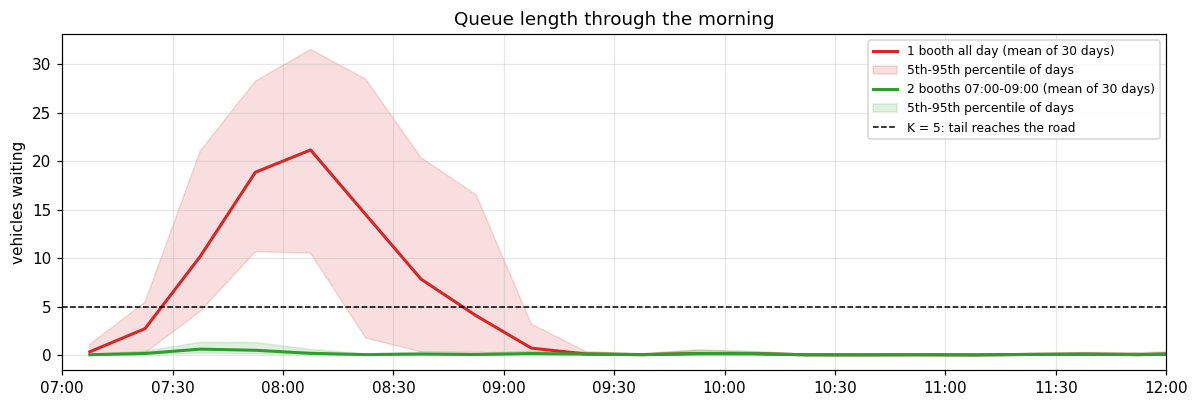

In [14]:
edges = np.arange(0, ps.DAY_LENGTH + ps.INTERVAL, ps.INTERVAL)
prof = {}
for cfg in [c.name for c in ps.CONFIGS]:
    prof[cfg] = np.array([ps.mean_queue_by_interval(days[(s, cfg)], edges) for s in SEEDS])
profile = pd.DataFrame({"interval_start": [ps.min_to_clock(t) for t in edges[:-1]]})
for cfg, m in prof.items():
    profile[f"{cfg} | mean"] = m.mean(0)
    profile[f"{cfg} | p05"] = np.percentile(m, 5, 0)
    profile[f"{cfg} | p95"] = np.percentile(m, 95, 0)
profile.to_csv(RESULTS / "queue_profile_by_interval.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
x = edges[:-1] + 7.5
for (cfg, m), col in zip(prof.items(), ["tab:red", "tab:green"]):
    ax.plot(x, m.mean(0), color=col, lw=2, label=f"{cfg} (mean of {N_REPS} days)")
    ax.fill_between(x, np.percentile(m, 5, 0), np.percentile(m, 95, 0), color=col, alpha=0.15, label="5th-95th percentile of days")
ax.axhline(K, color="k", ls="--", lw=1, label=f"K = {K}: tail reaches the road")
ax.set_xlim(0, 300); ax.set_xticks(np.arange(0, 301, 30)); ax.set_xticklabels([ps.min_to_clock(t) for t in range(0, 301, 30)])
ax.set_ylabel("vehicles waiting"); ax.set_title("Queue length through the morning"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "queue_profile.png"); plt.show()

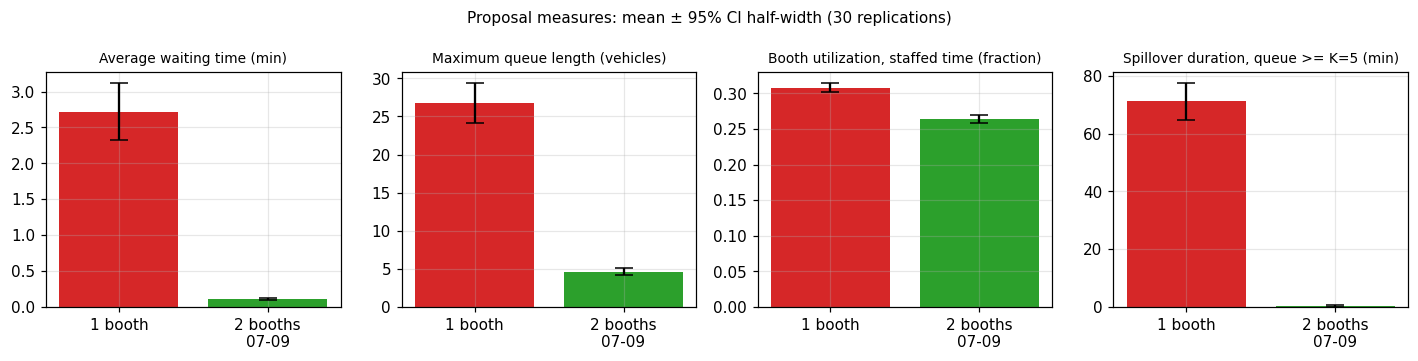

In [15]:
core = summary[summary.proposal_measure]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, (lab, g) in zip(axes, core.groupby("measure", sort=False)):
    ax.bar(range(len(g)), g["mean"], yerr=g["half_width"], capsize=6, color=["tab:red", "tab:green"])
    ax.set_xticks(range(len(g))); ax.set_xticklabels(["1 booth", "2 booths\n07-09"]); ax.set_title(lab, fontsize=9)
plt.suptitle("Proposal measures: mean ± 95% CI half-width (30 replications)", fontsize=10)
plt.tight_layout(); plt.savefig(FIGS / "measures_ci.png"); plt.show()

## 6. Were 30 replications enough?
Week 7 rule: *n* needed = *n* × (half-width now ÷ half-width wanted)², rounded up. The targets are **absolute precisions chosen from the decision**: waits to within ±0.25 min, spillover to within ±5 min, maximum queue to within ±2 vehicles, and utilization to within ±0.02. They apply to each configuration and to the paired difference, which is the quantity the decision actually rests on.

In [16]:
TARGET = {"avg_wait_min": 0.25, "spillover_min": 5.0, "max_queue_veh": 2.0, "utilization": 0.02}
plan = []
def plan_row(what, col, x):
    ci = ps.ci_mean(x)
    need = ps.replications_needed(len(x), ci["half_width"], TARGET[col])
    plan.append({"quantity": what, "mean": ci["mean"], "half_width": ci["half_width"], "target_half_width": TARGET[col],
                 "reps_needed": need, "30_is_enough": need <= N_REPS})
for col in TARGET:
    for cfg in [c.name for c in ps.CONFIGS]:
        plan_row(f"{col} | {cfg}", col, exp_df.loc[exp_df.config == cfg, col].to_numpy())
    plan_row(f"{col} | paired difference", col, (one[col] - two[col]).to_numpy())
plan = pd.DataFrame(plan); plan.to_csv(RESULTS / "replication_planning.csv", index=False); plan.round(3)

,quantity,mean,half_width,target_half_width,reps_needed,30_is_enough
0,avg_wait_min | 1 booth all day,2.720,0.400,0.25,77,False
1,avg_wait_min | 2 booths 07:00-09:00,0.113,0.011,0.25,1,True
2,avg_wait_min | paired difference,2.608,0.399,0.25,77,False
3,spillover_min | 1 booth all day,71.189,6.353,5.00,49,False
4,spillover_min | 2 booths 07:00-09:00,0.334,0.303,5.00,1,True
5,spillover_min | paired difference,70.855,6.350,5.00,49,False
6,max_queue_veh | 1 booth all day,26.800,2.603,2.00,51,False
7,max_queue_veh | 2 booths 07:00-09:00,4.633,0.410,2.00,2,True
8,max_queue_veh | paired difference,22.167,2.602,2.00,51,False
9,utilization | 1 booth all day,0.308,0.007,0.02,4,True


The proposal fixed 30 replications, and those are the main results above. Where 30 falls short of a target, Week 7 says to run the planned number and then **check the interval actually achieved**. The follow-up below reruns with the largest number required by a paired difference (seeds 1 to *n*, so the first 30 are the original replications).

In [17]:
def paired_ci_table(n):
    fu = ps.run_experiment(range(1, n + 1), rates, SERVICE, K)
    o2, t2 = [fu[fu.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS]
    rows = []
    for col in TARGET:
        ci = ps.ci_mean(o2[col] - t2[col])
        rows.append({"measure": col, "n": n, "diff_mean": ci["mean"], "half_width": ci["half_width"],
                     "target": TARGET[col], "target_met": ci["half_width"] <= TARGET[col],
                     "reps_needed_next": ps.replications_needed(n, ci["half_width"], TARGET[col]),
                     "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
    return pd.DataFrame(rows)

MAX_REPS = 400
n = int(plan[plan.quantity.str.contains("paired")]["reps_needed"].max())
rounds = []
if n > N_REPS:
    for it in range(1, 5):                      # "if you miss the target, apply it again"
        n = min(n, MAX_REPS)
        tab = paired_ci_table(n); tab.insert(0, "round", it); rounds.append(tab)
        if tab["target_met"].all() or n == MAX_REPS:
            break
        n = int(tab["reps_needed_next"].max())
    followup = pd.concat(rounds, ignore_index=True)
    followup.to_csv(RESULTS / "replication_followup.csv", index=False)
    print(f"Follow-up rounds (paired differences). Final n = {followup['n'].max()} replications per configuration.")
    display(followup.round(3))
else:
    print("30 replications already meet every paired-difference target; no follow-up run needed.")

Follow-up rounds (paired differences). Final n = 154 replications per configuration.


,round,measure,n,diff_mean,half_width,target,target_met,reps_needed_next,ci_low,ci_high
0,1,avg_wait_min,77,2.962,0.352,0.25,False,153,2.610,3.314
1,1,spillover_min,77,72.712,4.504,5.00,True,63,68.207,77.216
2,1,max_queue_veh,77,24.286,2.197,2.00,False,93,22.089,26.483
3,1,utilization,77,0.044,0.001,0.02,True,1,0.044,0.045
4,2,avg_wait_min,153,3.028,0.251,0.25,False,154,2.777,3.279
5,2,spillover_min,153,72.995,3.301,5.00,True,67,69.694,76.297
6,2,max_queue_veh,153,24.477,1.550,2.00,True,92,22.927,26.027
7,2,utilization,153,0.044,0.000,0.02,True,1,0.044,0.045
8,3,avg_wait_min,154,3.019,0.250,0.25,True,154,2.770,3.269
9,3,spillover_min,154,72.923,3.283,5.00,True,67,69.641,76.206


## 7. Validation: did we build the right model?
Validation compares the **baseline (1-booth)** model with the real system, using observations that were **not** used to fit inputs. Queue-length snapshots every 5 minutes during 07:00–09:00 (`data/validation_observations.csv`) serve this purpose, since the arrival and processing-time data never measured queue length.

One observed day is a single realization, so it is compared with the **spread of simulated days** (the 2.5th–97.5th percentile band), not with the confidence interval of the mean. Observed values that fall inside the band are *consistent with* the model. They do not prove it correct.

In [18]:
val = pd.read_csv(DATA / "validation_observations.csv")
snap_t = val["snapshot_time"].map(ps.clock_to_min).to_numpy()
sim_q = np.array([ps.queue_at_times(days[(s, ps.ONE_BOOTH.name)], snap_t) for s in SEEDS])
val["model_mean_queue"] = sim_q.mean(0)
val["model_p2_5"] = np.percentile(sim_q, 2.5, 0)
val["model_p97_5"] = np.percentile(sim_q, 97.5, 0)
obs = pd.to_numeric(val["queue_length_observed"], errors="coerce")
if obs.notna().any():
    val["inside_band"] = np.where(obs.notna(), (obs >= val["model_p2_5"]) & (obs <= val["model_p97_5"]), np.nan)
    share = val["inside_band"].dropna().mean()
    print(f"{share:.0%} of observed snapshots fall inside the model's 95% band of simulated days.")
else:
    print("Validation data not yet collected: the table shows the model's PREDICTION bands to compare against\n"
          "once queue-length snapshots are recorded on site (fill data/validation_observations.csv and rerun).")
val.to_csv(RESULTS / "validation_comparison.csv", index=False)
val.round(2).head(12)

Validation data not yet collected: the table shows the model's PREDICTION bands to compare against
once queue-length snapshots are recorded on site (fill data/validation_observations.csv and rerun).


,snapshot_time,queue_length_observed,model_mean_queue,model_p2_5,model_p97_5
0,07:05,NaN,0.37,0.00,2.27
1,07:10,NaN,0.37,0.00,3.27
2,07:15,NaN,0.30,0.00,2.27
3,07:20,NaN,2.27,0.00,6.27
4,07:25,NaN,3.20,0.00,8.00
5,07:30,NaN,4.20,0.00,12.82
6,07:35,NaN,9.17,0.73,24.00
7,07:40,NaN,11.97,3.72,25.65
8,07:45,NaN,15.10,5.90,30.28
9,07:50,NaN,17.77,8.18,30.37


**Extreme-condition checks** (face validity): with almost no traffic the wait should be about zero, and with heavy traffic the queue should grow and spillover should rise.

In [19]:
ext = []
for scale in [0.05, 1.0, 1.5]:
    d = ps.run_experiment(SEEDS[:10], rates, SERVICE, K, configs=[ps.ONE_BOOTH], arrival_scale=scale)
    ext.append({"arrival_scale": scale, "avg_wait_min": d.avg_wait_min.mean(), "spillover_min": d.spillover_min.mean(),
                "max_queue": d.max_queue_veh.mean()})
ext = pd.DataFrame(ext); ext.to_csv(RESULTS / "extreme_conditions.csv", index=False); ext.round(3)

,arrival_scale,avg_wait_min,spillover_min,max_queue
0,0.05,0.008,0.000,1.0
1,1.00,3.149,77.540,28.9
2,1.50,17.770,191.257,103.9


## 8. Sensitivity analysis: does the recommendation survive input errors?
### 8.1 Arrival rate × processing time
Arrival rates come from a single day, and processing times from 30 timings per window, so both are uncertain. Each cell of the grid reruns both configurations with 30 replications and CRN.

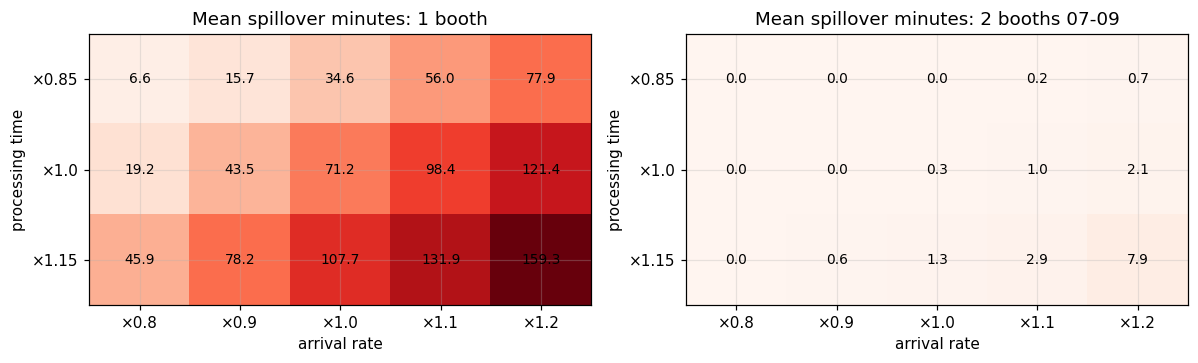

arrival_scale,0.8,0.9,1.0,1.1,1.2
service_scale,,,,,
0.85,0.28,0.49,0.94,1.71,2.77
1.00,0.66,1.35,2.61,4.53,6.78
1.15,1.56,3.24,5.68,8.72,11.98


In [20]:
A_SCALES, S_SCALES = [0.8, 0.9, 1.0, 1.1, 1.2], [0.85, 1.0, 1.15]
sens = []
for a_s in A_SCALES:
    for s_s in S_SCALES:
        d = ps.run_experiment(SEEDS, rates, SERVICE.with_scale(s_s), K, arrival_scale=a_s)
        o, t = [d[d.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS]
        for col in ["avg_wait_min", "spillover_min", "max_queue_veh"]:
            ci = ps.ci_mean(o[col] - t[col])
            sens.append({"arrival_scale": a_s, "service_scale": s_s, "measure": col,
                         "mean_1booth": o[col].mean(), "mean_2booths": t[col].mean(),
                         "diff": ci["mean"], "diff_ci_low": ci["ci_low"], "diff_ci_high": ci["ci_high"]})
sens = pd.DataFrame(sens); sens.to_csv(RESULTS / "sensitivity_arrival_service.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (cfg_col, title) in zip(axes, [("mean_1booth", "1 booth"), ("mean_2booths", "2 booths 07-09")]):
    piv = sens[sens.measure == "spillover_min"].pivot(index="service_scale", columns="arrival_scale", values=cfg_col)
    im = ax.imshow(piv.values, cmap="Reds", vmin=0, vmax=sens.loc[sens.measure == "spillover_min", "mean_1booth"].max(), aspect="auto")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.1f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(len(A_SCALES))); ax.set_xticklabels([f"×{a}" for a in A_SCALES]); ax.set_xlabel("arrival rate")
    ax.set_yticks(range(len(S_SCALES))); ax.set_yticklabels([f"×{s}" for s in S_SCALES]); ax.set_ylabel("processing time")
    ax.set_title(f"Mean spillover minutes: {title}")
plt.tight_layout(); plt.savefig(FIGS / "sensitivity_spillover.png"); plt.show()
sens[sens.measure == "avg_wait_min"].pivot(index="service_scale", columns="arrival_scale", values="diff").round(2)

### 8.2 Choice of processing-time distribution (same U values, different family)

In [21]:
fam_rows = []
for fam in ps.CANDIDATES:
    sm = service_model(fam)
    d = ps.run_experiment(SEEDS, rates, sm, K)
    for cfg in [c.name for c in ps.CONFIGS]:
        sub = d[d.config == cfg]
        for col in ["avg_wait_min", "spillover_min"]:
            ci = ps.ci_mean(sub[col])
            fam_rows.append({"family": fam, "selected": all(chosen[w] == fam for w in chosen), "configuration": cfg,
                             "measure": col, "mean": ci["mean"], "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
fam_df = pd.DataFrame(fam_rows); fam_df.to_csv(RESULTS / "sensitivity_distribution.csv", index=False)
fam_df.pivot_table(index=["measure", "configuration"], columns="family", values="mean").round(3)

family                              exponential  lognormal  triangular
measure       configuration                                           
avg_wait_min  1 booth all day             3.409      2.720       5.555
              2 booths 07:00-09:00        0.188      0.113       0.175
spillover_min 1 booth all day            76.189     71.189     105.126
              2 booths 07:00-09:00        1.753      0.334       1.201

### 8.3 Approach capacity *K* ± 1 vehicle (same runs, different threshold)

In [22]:
kcols = {f"K={max(K-1,1)}": f"spillover_min_K{max(K-1,1)}", f"K={K}": "spillover_min", f"K={K+1}": f"spillover_min_K{K+1}"}
k_df = pd.DataFrame({lab: exp_df.groupby("config")[col].mean() for lab, col in kcols.items()})
k_df.to_csv(RESULTS / "sensitivity_K.csv"); k_df.round(2)

,K=4,K=5,K=6
config,,,
1 booth all day,75.45,71.19,67.28
2 booths 07:00-09:00,1.20,0.33,0.07


## 9. Result statement and evidence summary

In [23]:
def p(col): return paired.set_index("measure").loc[MEASURES[col][0]]
def s(cfg, col): return summary[(summary.configuration == cfg) & (summary.measure == MEASURES[col][0])].iloc[0]
o_w, t_w = s(ps.ONE_BOOTH.name, "avg_wait_min"), s(ps.TWO_BOOTH_PEAK.name, "avg_wait_min")
o_s, t_s = s(ps.ONE_BOOTH.name, "spillover_min"), s(ps.TWO_BOOTH_PEAK.name, "spillover_min")
sp = sens[sens.measure == "spillover_min"]
robust = bool((sp["diff_ci_low"] > 0).all() | (sp["mean_1booth"] < 0.5).all())
wins = int((sp["diff_ci_low"] > 0).sum())

text = (f"Over {N_REPS} replicated high-traffic days (terminating study, 07:00 to queue cleared, no warm-up, seeds 1-{N_REPS}, "
        f"common random numbers), one booth gave a mean wait of {o_w['mean']:.2f} min (95% CI {o_w['ci_low']:.2f} to {o_w['ci_high']:.2f}) "
        f"and {o_s['mean']:.1f} min of spillover onto Pablo Ocampo Sr. Extension (95% CI {o_s['ci_low']:.1f} to {o_s['ci_high']:.1f}). "
        f"A second booth from 07:00 to 09:00 gave {t_w['mean']:.2f} min mean wait and {t_s['mean']:.1f} min of spillover; "
        f"the paired reduction in spillover is {p('spillover_min')['diff_mean']:.1f} min "
        f"(95% CI {p('spillover_min')['diff_ci_low']:.1f} to {p('spillover_min')['diff_ci_high']:.1f}). "
        f"{int(ver['pass'].sum())}/{len(ver)} verification checks passed. The second booth reduced spillover significantly in "
        f"{wins} of {len(sp)} arrival/processing-time sensitivity cells.")
print(text)
if PLACEHOLDER:
    print("\n[PLACEHOLDER INPUTS - illustrative only. Replace data/ with field observations before reporting.]")

evidence = pd.DataFrame([
    ["Precision", "Mean with 95% CI and n", f"n = {N_REPS} per configuration; paired CI on differences"],
    ["Study design", "Type, run length, warm-up, seeds", f"Terminating, 07:00 to clearance, no warm-up, seeds 1-{N_REPS}, CRN"],
    ["Verification", "Checks run and passed", f"{int(ver['pass'].sum())}/{len(ver)} (results/verification_checks.csv)"],
    ["Validation", "Comparison with real data", "Pending field snapshots" if pd.to_numeric(pd.read_csv(DATA / 'validation_observations.csv')['queue_length_observed'], errors='coerce').isna().all() else "results/validation_comparison.csv"],
    ["Sensitivity", "Does the advice survive input changes?", f"Spillover reduced significantly in {wins}/{len(sp)} cells; distribution family and K±1 in 8.2-8.3"],
], columns=["evidence", "what to show", "this study"])
evidence.to_csv(RESULTS / "evidence_summary.csv", index=False); evidence

Over 30 replicated high-traffic days (terminating study, 07:00 to queue cleared, no warm-up, seeds 1-30, common random numbers), one booth gave a mean wait of 2.72 min (95% CI 2.32 to 3.12) and 71.2 min of spillover onto Pablo Ocampo Sr. Extension (95% CI 64.8 to 77.5). A second booth from 07:00 to 09:00 gave 0.11 min mean wait and 0.3 min of spillover; the paired reduction in spillover is 70.9 min (95% CI 64.5 to 77.2). 11/11 verification checks passed. The second booth reduced spillover significantly in 15 of 15 arrival/processing-time sensitivity cells.

[PLACEHOLDER INPUTS - illustrative only. Replace data/ with field observations before reporting.]


,evidence,what to show,this study
0,Precision,Mean with 95% CI and n,n = 30 per configuration; paired CI on differe...
1,Study design,"Type, run length, warm-up, seeds","Terminating, 07:00 to clearance, no warm-up, s..."
2,Verification,Checks run and passed,11/11 (results/verification_checks.csv)
3,Validation,Comparison with real data,Pending field snapshots
4,Sensitivity,Does the advice survive input changes?,Spillover reduced significantly in 15/15 cells...


### Limitations
- **Arrival data from one day.** Each 15-minute rate rests on a single count. Several high-traffic days would tighten the rates; section 8.1 shows how much the answer moves if they are off by ±20%.
- **Gate-log censoring.** Unless the peak tally file is filled in, peak arrival rates come from booth passages and understate demand. The true one-booth congestion may then be worse than reported.
- **Shared-queue assumption (A3).** If the approach forms two separate lanes and drivers pick one, two-booth performance will be somewhat worse than modelled.
- **Empty start at 07:00 (A7).** If vehicles queue before the booth opens, the morning is under-estimated. Record the queue at 07:00 on the observation day.
- **No balking or reneging.** Real drivers facing a long line may divert, which would lower the queue but also represents lost entries. This is out of scope per the proposal.
- The model estimates queueing performance only. Whether the reduction justifies an extra attendant is a management judgment about cost, which the proposal leaves outside the model.